In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/home/jolivera/Documents/CloudSkin/Time-Series-Library/dataset/training_dataset/new_queues_concurrency_4_after_migration/preprocessed_data_ets.csv')

In [3]:
df.drop(columns=['pipelines_status_avg_fps',
       'pipelines_status_avg_pipeline_latency', 'node_cpu_usage',
       'node_mem_usage', 'pipelines_server_cpu_usage',
       'pipelines_server_mem_usage', 'number_pipelines'], inplace=True)

In [4]:
df=df[['date','cluster','pipelines_status_realtime_pipeline_latency']]
df_edge=df[df['cluster']=='eb0e3eaa-b668-4ad6-bc10-2bb0eb7da259']
df_edge.drop(columns=['cluster'], inplace=True)
df_cloud=df[df['cluster']=='fd7816db-7948-4602-af7a-1d51900792a7']
df_cloud.drop(columns=['cluster'], inplace=True)

df_separated={"df_edge":df_edge,"df_cloud":df_cloud}

/tmp/ipykernel_297826/3503316258.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_edge.drop(columns=['cluster'], inplace=True)
/tmp/ipykernel_297826/3503316258.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cloud.drop(columns=['cluster'], inplace=True)


In [5]:
print(df_separated["df_edge"].shape)
print(df_separated["df_cloud"].shape)

(33089, 2)
(33092, 2)


In [6]:
for x in df_separated:
    df=df_separated[x]
    df["date"]=pd.to_datetime(df["date"])
    full_range=pd.date_range(start=df["date"].min(), end=df["date"].max(), freq='30s')
    df = df.set_index(["date"]).reindex(full_range).rename_axis("date").reset_index()

    df["pipelines_status_realtime_pipeline_latency"] = (
        df["pipelines_status_realtime_pipeline_latency"].fillna(0)
    )
    df_separated[x]=df


In [7]:
print(df_separated["df_edge"].shape)
print(df_separated["df_cloud"].shape)

(98879, 2)
(98879, 2)


In [8]:
# We detected 2 days with wrong data. We remove them and clear the gap.
bad_days = [
    "2025-08-06",
    "2025-08-24"
]
bad_days = pd.to_datetime(bad_days)
df = df_separated["df_edge"]
df["date"]=pd.to_datetime(df["date"])
df = df[~df.date.dt.date.isin(bad_days.date)]
new_time = pd.date_range(start=df.date.iloc[0], periods=len(df), freq="30s")
df["date"] = new_time
df=df.reset_index(drop=True)
df_separated["df_edge"]=df

/tmp/ipykernel_297826/3381591369.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = new_time


In [9]:
print(df_separated["df_edge"].shape)
print(df_separated["df_cloud"].shape)

(93119, 2)
(98879, 2)


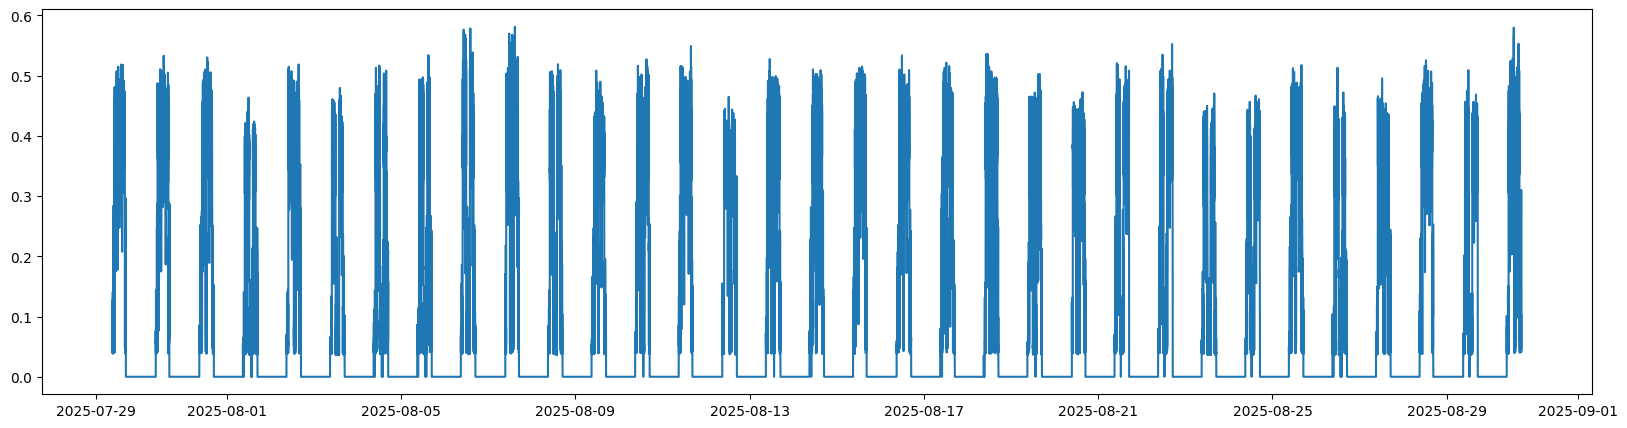

In [10]:
plt.figure(figsize=(20, 5))
plt.plot(df_separated["df_edge"]["date"],df_separated["df_edge"]["pipelines_status_realtime_pipeline_latency"])
plt.show()

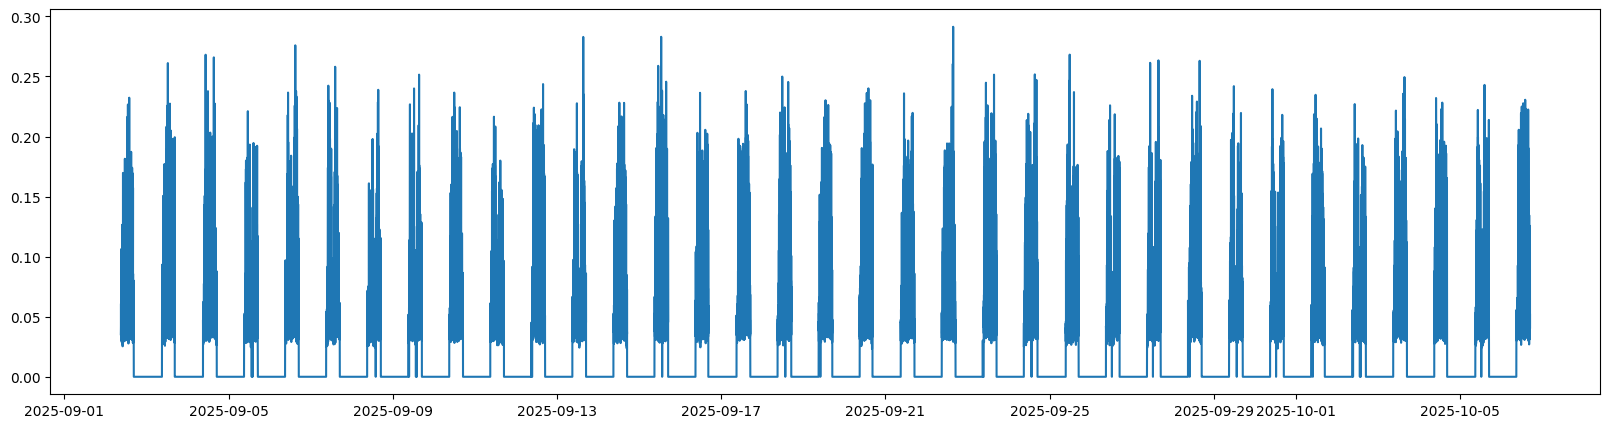

In [11]:
plt.figure(figsize=(20, 5))
plt.plot(df_separated["df_cloud"]["date"],df_separated["df_cloud"]["pipelines_status_realtime_pipeline_latency"])
plt.show()

In [12]:
df_separated["df_edge"].to_csv('/home/jolivera/Documents/CloudSkin/Time-Series-Library/dataset/training_dataset/new_queues_concurrency_4_after_migration/preprocessed_data_ets_edge.csv',index=False)
df_separated["df_cloud"].to_csv('/home/jolivera/Documents/CloudSkin/Time-Series-Library/dataset/training_dataset/new_queues_concurrency_4_after_migration/preprocessed_data_ets_cloud.csv',index=False)

# Fitting ETS

In [13]:
from statsmodels.tsa.api import ExponentialSmoothing


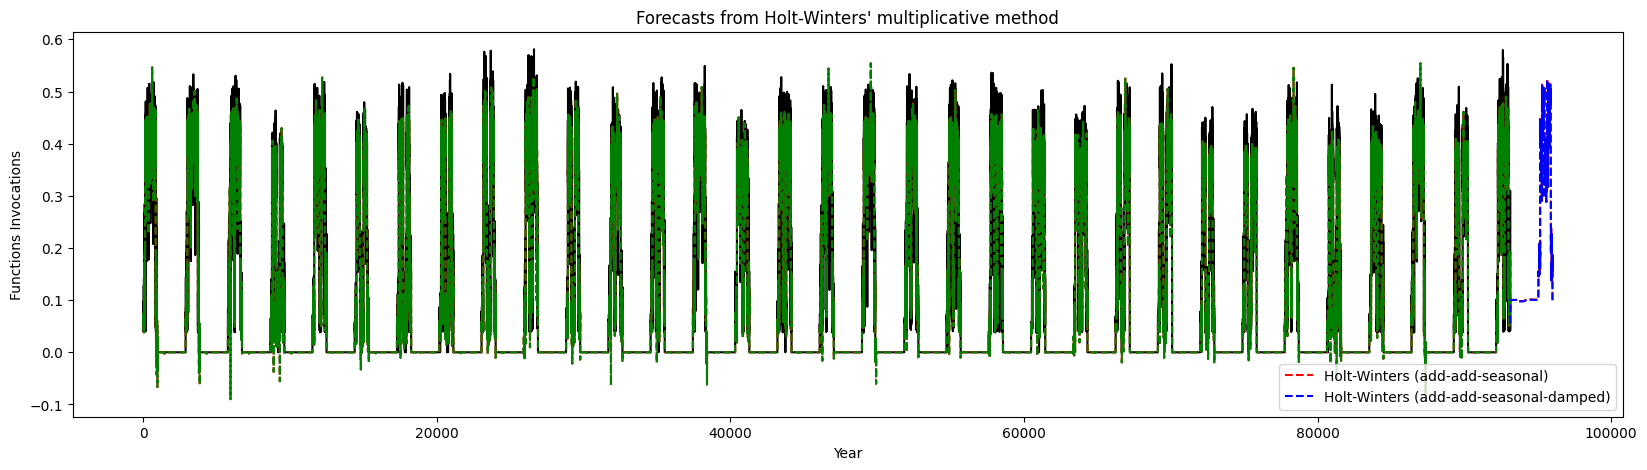

,Additive,Additive Dam
$\alpha$,3.019050e-01,3.019039e-01
$\beta$,0.000000e+00,0.000000e+00
$\phi$,NaN,9.864637e-01
$\gamma$,6.685772e-02,6.685792e-02
$l_0$,1.062636e-01,1.062636e-01
$b_0$,6.050697e-07,6.050697e-07
SSE,8.171096e+01,8.171096e+01


In [ ]:
# ETS: Exponential Smoothing
ets_1 = ExponentialSmoothing(df_separated["df_edge"]["pipelines_status_realtime_pipeline_latency"],seasonal_periods=2880, trend="add", seasonal="add",damped_trend=False, initialization_method="heuristic").fit()
ets_3 = ExponentialSmoothing(df_separated["df_edge"]["pipelines_status_realtime_pipeline_latency"],seasonal_periods=2880, trend="add", seasonal="add",damped_trend=True, initialization_method="heuristic").fit()
results = pd.DataFrame(
    index=[r"$\alpha$", r"$\beta$", r"$\phi$", r"$\gamma$", r"$l_0$", "$b_0$", "SSE"]
)
params = [
    "smoothing_level",
    "smoothing_trend",
    "damping_trend",
    "smoothing_seasonal",
    "initial_level",
    "initial_trend",
]
results["Additive"] = [ets_1.params[p] for p in params] + [ets_1.sse]
results["Additive Dam"] = [ets_3.params[p] for p in params] + [ets_3.sse]

ax = df_separated["df_edge"]["pipelines_status_realtime_pipeline_latency"].plot(
    figsize=(20, 5),
    color="black",
    title="Forecasts from Holt-Winters' multiplicative method",
)
ax.set_ylabel("Pipeline Latency")
ax.set_xlabel("Year")
ets_1.fittedvalues.plot(ax=ax, style="--", color="red")
ets_3.fittedvalues.plot(ax=ax, style="--", color="green")

ets_1.forecast(2880).rename("Holt-Winters (add-add-seasonal)").plot(
    ax=ax, style="--", color="red", legend=True
)
ets_3.forecast(2880).rename("Holt-Winters (add-add-seasonal-damped)").plot(
    ax=ax, style="--", color="blue", legend=True
)

plt.show()

results